In [1]:
import ast
import os
import pandas as pd

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


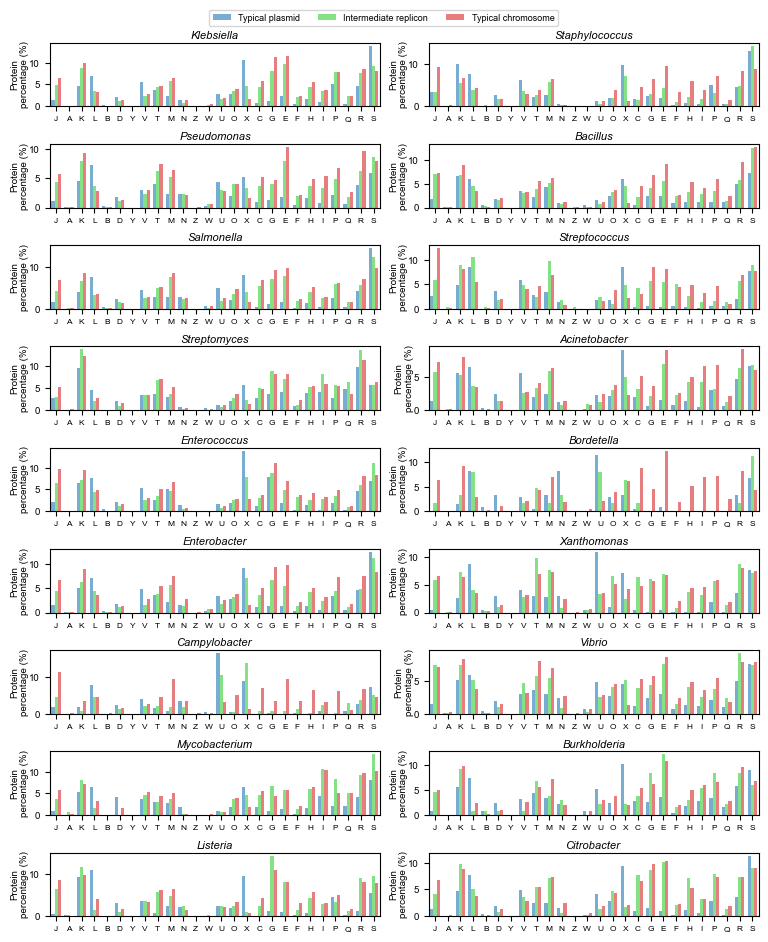

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

plt.rcParams["font.family"] = ['Arial']
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

fig = plt.figure(figsize=(7.5, 7.5))

base_folder = f'/active-data/analysis_results/chr_pla/genus'
i = 0
gap = 0.015

for genus_name in keep_genus:
    if genus_name == 'Escherichia':
        continue
    os.chdir(f'{base_folder}/statistics_records/{genus_name}')
    rep_COG_data = pd.read_csv('COG_statistics.tsv', sep='\t')
    replicon_data = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
    merged_data = pd.merge(rep_COG_data, replicon_data[['accession', 'category-pident_90']], on='accession', how='left')
    # print(merged_data)
    numeric_cols = merged_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
    sum_df = merged_data.groupby('category-pident_90')[numeric_cols].sum().reset_index()

    denominator_col = "All coding CDSs"
    # denominator_col = "Categorized CDSs"

    exclude_cols = ["accession", "All coding CDSs", "Categorized CDSs", "category-pident_90"]
    letter_cols = [col for col in sum_df.columns if col not in exclude_cols]
    pct_df = sum_df.copy()
    for col in letter_cols:
        pct_df[f"{col}_%"] = (pct_df[col] / pct_df[denominator_col] * 100)
    result = pct_df[["category-pident_90", denominator_col] + [f"{c}_%" for c in letter_cols]]

    # print(result)
    if result.isnull().any().any() or 'intermediate replicon' not in result["category-pident_90"].to_list():
        continue
    
    i += 1
    rep_y_site = 1 - 0.12*int((i + 1)/2) - gap*int((i - 1)/2)
    ax = fig.add_axes([0.055 + 0.505*((i + 1)%2), rep_y_site, 0.5-0.06, 0.085])
    
    target_order = ['typical plasmid', 'intermediate replicon', 'typical chromosome']
    colors = [plt.cm.tab10(0), "#32CD32", plt.cm.tab10(3)]

    letter_pct_cols = result.columns[2:]
    x = np.arange(len(letter_pct_cols))
    width = 0.75 / 3

    all_row_data = []

    for idx, lab in enumerate(target_order):
        row_data = result[result['category-pident_90'] == lab][letter_pct_cols].values
        all_row_data.append(row_data)
        if len(row_data) == 0:
            row_data = np.zeros((1, len(letter_pct_cols)))
        rects1 = ax.bar(x + width*(-1+idx), row_data[0], width, label=lab.capitalize(), color=colors[idx], alpha=0.6)
    
    #ax.set_xlabel("COG category")
    ax.set_ylabel("Protein\npercentage (%)", labelpad=0)
    ax.set_xticks(x)
    ax.set_xticklabels([col.replace("_%", "") for col in letter_pct_cols])
    ax.set_title(genus_name, fontstyle='italic', pad=3)
    ax.set_xlim(-0.5, len(letter_pct_cols)-0.5)

replicon_elements = [Patch(facecolor=plt.cm.tab10(0),label='Typical plasmid', alpha=0.6), 
                     Patch(facecolor="#32CD32",label='Intermediate replicon', alpha=0.6), 
                     Patch(facecolor=plt.cm.tab10(3),label='Typical chromosome', alpha=0.6)]
fig.legend(handles=replicon_elements, loc='upper center',bbox_to_anchor=(0.5,1.015),ncol=3)

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
#fig.patches.append(rect)

figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_all_genera_cog_count.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_all_genera_cog_count.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()